# Season track map — one basin, one season

Plot **all storm tracks** for the 2005 North Atlantic season as `LineString`s, coloured by each storm's maximum Saffir-Simpson category, and annotate the strongest storm.

Uses `geometry='track'`, which returns one `LineString` per storm with summary attributes (`max_vmax_kt`, `min_mslp_hpa`, `max_category`, `ace`). Needs `pip install earthlens[tropycal]`.

In [1]:
from pathlib import Path

from earthlens import EarthLens

OUT_DIR = Path('tropycal_output')
OUT_DIR.mkdir(exist_ok=True)

tracks = None
try:
    tracks = EarthLens(
        variables=['north_atlantic'],
        data_source='tropycal',
        start='2005-06-01',
        end='2005-12-01',
        aoi=[-110.0, 0.0, -10.0, 60.0],
        source='hurdat',
        geometry='track',
        path=str(OUT_DIR),
    ).download(progress_bar=False)
    print(len(tracks), 'storm tracks')
except Exception as exc:
    print(f'skipped live query: {type(exc).__name__}: {exc}')

2026-05-23 18:04:37 | INFO | pyramids.base.config | Logging is configured.


C:\python-environments\pixi\envs\earthlens-7782220113782294872\envs\dev\Lib\site-packages\tropycal\_version.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution


2026-05-23 18:04:39.920 | INFO     | earthlens.tropycal.backend:_get_track_dataset:378 - Loading tropycal TrackDataset(basin='north_atlantic', source='hurdat'); the first load downloads + parses the whole basin best-track file and can be slow.


--> Starting to read in HURDAT2 data


--> Completed reading in HURDAT2 data (3.13 seconds)


2026-05-23 18:04:53 | INFO | pyogrio._io | Created 30 records


2026-05-23 18:04:53.035 | INFO     | earthlens.tropycal.backend:download:514 - Tropycal download summary: 30 feature(s) across 1 file(s) written to C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\tropycal\docs\examples\tropycal\tropycal_output


30 storm tracks


## Strongest storm of the season

In [2]:
if tracks is not None and len(tracks):
    strongest = tracks.sort_values('max_vmax_kt', ascending=False).iloc[0]
    print(strongest['name'], '- max wind', strongest['max_vmax_kt'], 'kt,'
          ' min pressure', strongest['min_mslp_hpa'], 'hPa')

WILMA - max wind 160.0 kt, min pressure 882.0 hPa


## Map all tracks coloured by max category

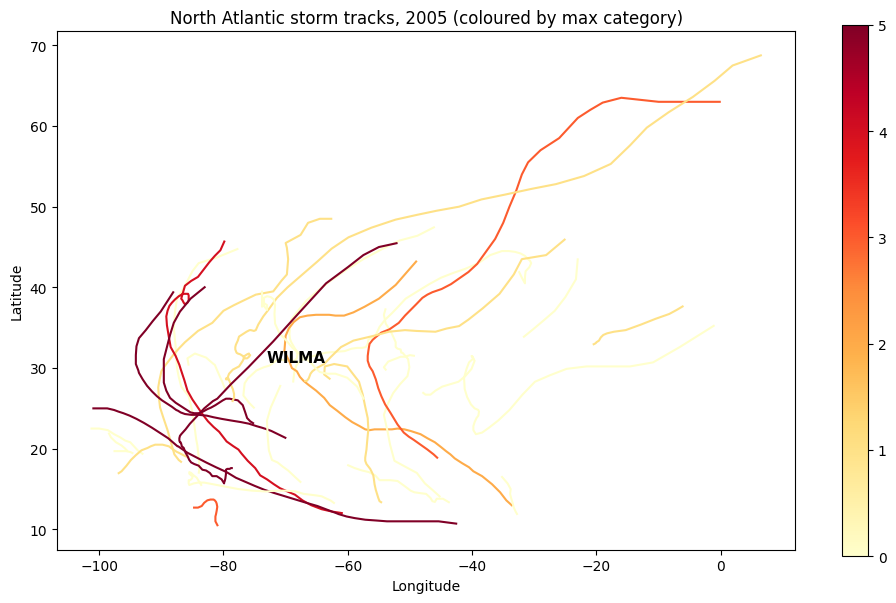

In [3]:
if tracks is not None and len(tracks):
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(10, 6))
    tracks.plot(ax=ax, column='max_category', cmap='YlOrRd', legend=True,
                linewidth=1.5)
    strongest = tracks.sort_values('max_vmax_kt', ascending=False).iloc[0]
    cx, cy = strongest.geometry.centroid.x, strongest.geometry.centroid.y
    ax.annotate(strongest['name'], xy=(cx, cy), fontsize=11, fontweight='bold')
    ax.set_title('North Atlantic storm tracks, 2005 (coloured by max category)')
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    plt.tight_layout()
    plt.show()